In [45]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt

def find_spectra_file(filename='spectra_archive.npz'):
    # Check a few common locations first (IF YOU HAVE A LARGE DRIVE YOU MIGHT WANT TO PUT THE ARCHIVE IN A COMMON LOCATION)
    checks = [
        os.path.join(os.getcwd(), filename),
        os.path.join(os.path.expanduser('~'), filename),
        os.path.join(os.path.expanduser('~'), 'Desktop', filename),
        os.path.join(os.path.expanduser('~'), 'Downloads', filename),
        os.path.join(os.path.expanduser('~'), 'Documents', filename)
    ]
    for p in checks:
        if os.path.exists(p):
            return p

    # Look for OneDrive folders under the user's home (common on Windows) Add # If this isn't necessary
    home = os.path.expanduser('~')
    try:
        for entry in os.listdir(home):
            # Match folders named 'OneDrive' or starting with 'OneDrive' (e.g. 'OneDrive - Personal')
            if entry.lower().startswith('onedrive'):
                od = os.path.join(home, entry)
                candidates = [
                    os.path.join(od, filename),
                    os.path.join(od, 'Desktop', filename),
                    os.path.join(od, 'Documents', filename),
                ]
                for c in candidates:
                    if os.path.exists(c):
                        return c
    except Exception:
        pass

    # If not found, search all available drives (Windows) or root ('/') on Unix-like systems (Again If you have a large drive...)
    roots = []
    if os.name == 'nt':
        for letter in string.ascii_uppercase:
            root = f'{letter}:\\'
            if os.path.exists(root):
                roots.append(root)
    else:
        roots.append('/')

    for root in roots:
        for dirpath, dirnames, filenames in os.walk(root):
            if filename in filenames:
                return os.path.join(dirpath, filename)
    return None

# Try to find the file automatically (Calls the find spectra function and names the file_path to where the file was found)
file_path = find_spectra_file('spectra_archive.npz')
if file_path is None:
    print('Could not find spectra_archive.npz automatically.')
    print('Place the file in this notebook folder or your Desktop/Downloads, or install it on a reachable drive.')
    raise FileNotFoundError('spectra_archive.npz not found')
else:
    print(f'Loading spectra from: {file_path}')
    data = np.load(file_path)
    print(data.files)  # List all arrays in the .npz file

# Insert here all the arrays in the .npz archive
keys = [
    "A2V_wl", "A2V_flux",
    "A6V_wl", "A6V_flux", "A9V_wl", "A9V_flux",
    "B1V_wl", "B1V_flux", "B6V_wl", "B6V_flux",
    "F0V_wl", "F0V_flux", "F5V_wl", "F5V_flux",
    "F9V_wl", "F9V_flux",
    "G6V_wl", "G6V_flux", "G9V_wl", "G9V_flux",
    "K0V_wl", "K0V_flux", "K4V_wl", "K4V_flux",
    "M0V_wl", "M0V_flux", "M1V_wl", "M1V_flux", "M5V_wl", "M5V_flux",
    "O5V_wl", "O5V_flux", "O8V_wl", "O8V_flux", "G2V_wl", "G2V_flux",
]

# If the key you've added isn't there it gives you this error
available = set(data.files)
for name in keys:
    if name in available:
        globals()[name] = data[name]
    else:
        print(f"Warning: {name} not found in the .npz archive")

Loading spectra from: c:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\spectra_archive.npz
['A2V_wl', 'A2V_flux', 'A6V_wl', 'A6V_flux', 'A9V_wl', 'A9V_flux', 'B1V_wl', 'B1V_flux', 'B6V_wl', 'B6V_flux', 'F0V_wl', 'F0V_flux', 'F5V_wl', 'F5V_flux', 'F9V_wl', 'F9V_flux', 'G2V_wl', 'G2V_flux', 'G6V_wl', 'G6V_flux', 'G9V_wl', 'G9V_flux', 'K0V_wl', 'K0V_flux', 'K4V_wl', 'K4V_flux', 'M0V_wl', 'M0V_flux', 'M1V_wl', 'M1V_flux', 'M5V_wl', 'M5V_flux', 'O5V_wl', 'O5V_flux', 'O8V_wl', 'O8V_flux']


In [ ]:
try:
    # Build spectra dict from loaded arrays (pairs like NAME_wl and NAME_flux)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    import matplotlib.pyplot as plt
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        if len(spectra) == 0:
            print('No spectra to select.')
        else:
            dropdown = widgets.Dropdown(options=sorted(spectra.keys()), description='Spectrum:')
            out = widgets.Output()

            def on_change(change, out=out):
                # bind `out` so this closure writes only to this cell's Output widget
                if change.get('name') == 'value':
                    with out:
                        clear_output(wait=True)
                        n = change.get('new')
                        wl = spectra[n]['wl']
                        flux = spectra[n]['flux']
                        plt.figure(figsize=(9,4))
                        plt.plot(wl, flux, lw=0.8)
                        plt.xlabel('Wavelength (Å)')
                        plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
                        plt.title(n)
                        plt.grid(True)
                        plt.show()

            dropdown.observe(on_change, names='value')
            display(dropdown, out)
    except Exception as e:
        print('To enable interactive selection install ipywidgets:')
        print('pip install ipywidgets')
        print('Then enable notebook extension if needed (classic notebook). Error:', e)
except Exception as e:
    print('Error building spectra dictionary:', e)

Dropdown(description='Spectrum:', options=('A2V', 'A6V', 'A9V', 'B1V', 'B6V', 'F0V', 'F5V', 'F9V', 'G2V', 'G6V…

Output()

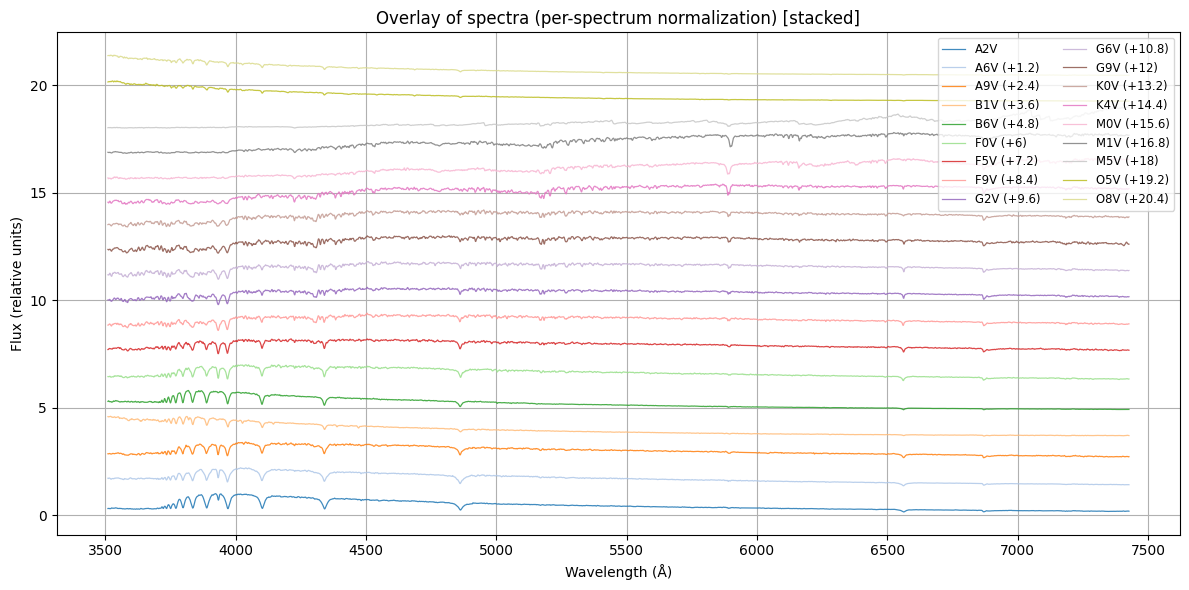

In [47]:
# Overlay with per-spectrum scaling (optionally stack vertically using offsets)
try:
    # Rebuild spectra dict in case it's not present in this scope
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    if len(spectra) == 0:
        print('No spectra available to plot. Make sure the .npz file was loaded successfully.')
    else:
        # Per-spectrum scaling: set scalars here (keys are spectrum names without _wl/_flux)
        # Example: scales = {'A2V': 1.0, 'G9V': 0.5} to plot G9V at half the height of A2V (THIS ISN'T NECESSARY WHEN USING STACKING)
        scales = {
            'A2V': 1.0,
            'A6V': 1.0,
            'A9V': 1.0,
            'B1V': 1.0,
            'B6V': 1.0,
            'F0V': 1.0,
            'F5V': 1.0,
            'F9V': 1.0,
            'G2V': 1.0,
            'G6V': 1.0,
            'G9V': 1.0,
            'K0V': 1.0,
            'K4V': 1.0,
            'M0V': 1.0,
            'M1V': 1.0,
            'M5V': 1.0,
            'O5V': 1.0,
            'O8V': 1.0,
        }

        # Option: stack spectra vertically instead of plotting on the same baseline.
        # - Set `offset_mode = False` to keep the overlay behavior.
        # - If `offset_mode = True` you can provide per-spectrum additive offsets in `offsets`.
        # - When stacking we use per-spectrum normalization and then apply `scales` so multipliers
        #   increase the apparent height of a spectrum within its stack position (ladder behavior).
        offset_mode = True
        offsets = {name: 0.0 for name in spectra.keys()}  # user-editable per-spectrum offsets (additive, in the same units as plotted values)

        # Decide normalization mode for non-stacked plots:
        # - If all scales == 1.0 -> use per-spectrum normalization (original behavior)
        # - If any scale != 1.0 -> compute global max after scaling and normalize by that (preserve relative amplitudes)
        use_global_norm = any(v != 1.0 for v in scales.values())
        if offset_mode:
            # For stacked plotting we prefer per-spectrum normalization so each spectrum retains its own shape.
            use_global_norm = False

        # First compute (optionally scaled) maxima if global normalization is requested
        global_max = 0.0
        if use_global_norm:
            for name, s in spectra.items():
                raw_f = np.asarray(s['flux'], dtype=float)
                f = raw_f * scales.get(name, 1.0)
                if f.size == 0:
                    continue
                m = np.nanmax(np.abs(f))
                if np.isfinite(m) and m > global_max:
                    global_max = m

        import matplotlib.pyplot as plt
        cmap = plt.get_cmap('tab20')
        plt.figure(figsize=(12, 6))

        # Precompute plotted fluxes so we can apply automatic offsets when requested
        plotted = {}
        names_sorted = sorted(spectra.keys())
        for name in names_sorted:
            wl = np.asarray(spectra[name]['wl'], dtype=float)
            raw_f = np.asarray(spectra[name]['flux'], dtype=float)
            if raw_f.size == 0:
                plotted[name] = (wl, raw_f, 0.0)
                continue

            if use_global_norm:
                # global normalization: scale applied before normalization so relative amplitudes preserved
                f_scaled = raw_f * scales.get(name, 1.0)
                if global_max > 0:
                    f_plot = f_scaled / global_max
                else:
                    f_plot = f_scaled
            else:
                # per-spectrum normalization
                maxval = np.nanmax(np.abs(raw_f))
                if maxval == 0 or np.isnan(maxval):
                    f_norm = raw_f
                else:
                    f_norm = raw_f / maxval
                # If stacking, multiply by scale after normalization so scale increases apparent height
                if offset_mode:
                    f_plot = f_norm * scales.get(name, 1.0)
                else:
                    # non-stacked per-spectrum normalization already accounts for scale via earlier branch
                    f_plot = f_norm

            # store peak for automatic spacing
            peak = 0.0
            try:
                peak = float(np.nanmax(np.abs(f_plot))) if f_plot.size else 0.0
            except Exception:
                peak = 0.0

            plotted[name] = (wl, f_plot, peak)

        # If offset_mode is enabled, compute final offsets
        final_offsets = {name: float(offsets.get(name, 0.0)) for name in names_sorted}
        if offset_mode:
            # if user didn't provide any non-zero offsets, create automatic spacing
            if all(v == 0.0 for v in final_offsets.values()):
                # Determine a spacing based on the median peak of the plotted spectra
                peaks = [p[2] for p in plotted.values() if p[2] is not None and p[2] > 0]
                if len(peaks) == 0:
                    sep = 1.0
                else:
                    sep = 1.2 * float(np.nanmedian(peaks))
                    if sep == 0 or not np.isfinite(sep):
                        sep = 1.0
                for i, name in enumerate(names_sorted):
                    final_offsets[name] = i * sep
            # otherwise keep user-specified offsets (already in final_offsets)

        # Plot each spectrum, applying offsets when requested
        ax = plt.gca()
        for i, name in enumerate(names_sorted):
            wl, f_plot, _ = plotted[name]
            if f_plot.size == 0:
                continue

            offset = final_offsets.get(name, 0.0) if offset_mode else 0.0
            label = name
            # For stacked plots we applied scales to plotted values; for non-stacked we indicate scale in label
            if not offset_mode and scales.get(name, 1.0) != 1.0:
                label = f"{name} (×{scales.get(name)})"
            if offset_mode and float(offset) != 0.0:
                label = f"{label} (+{offset:g})"

            ax.plot(wl, f_plot + offset, label=label, color=cmap(i % 20), lw=0.9, alpha=0.85)

        # Ensure axis limits include stacked offsets
        ax.relim()
        ax.autoscale_view()

        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux (relative units)')
        title_extra = ' (global normalization)' if use_global_norm else ' (per-spectrum normalization)'
        if offset_mode:
            title_extra += ' [stacked]'
        plt.title('Overlay of spectra' + title_extra)
        plt.grid(True)
        try:
            plt.legend(loc='upper right', fontsize='small', ncol=2)
        except Exception:
            plt.legend(fontsize='small')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Error plotting overlay with per-spectrum scaling:', e)

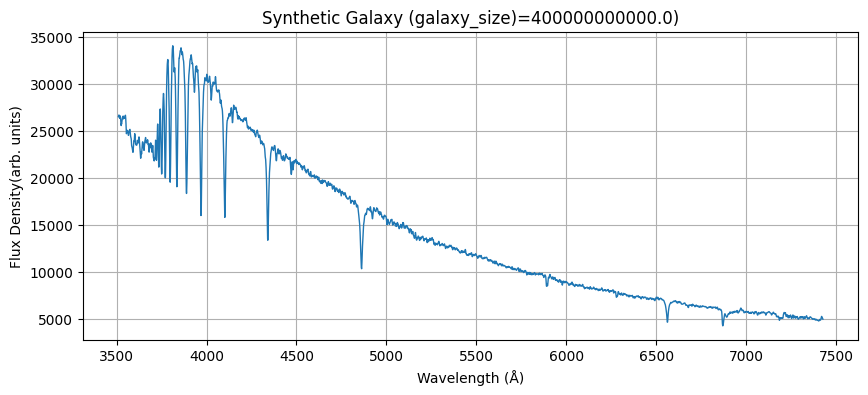

Output()

In [ ]:
# Build class spectra and galaxy builder (per-class multipliers) with per-member weights
# Usage examples:
#   set_class_member_weights('O', {'O5V':0.25, 'O8V':0.75})
#   wl_o, flux_o = build_class_spectrum('O')
#   wl_gal, flux_gal = build_galaxy_spectrum({'O':50, 'G':1000})
try:
    # Ensure spectra dict exists (rebuild from globals if necessary)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    # Define class membership for available spectra (Theoretically we could include every single star type)
    classes = {
        'O': ['O5V', 'O8V'],
        'B': ['B1V', 'B6V'],
        'A': ['A2V', 'A6V', 'A9V'],
        'F': ['F0V', 'F5V', 'F9V'],
        'G': ['G6V', 'G9V', 'G2V'],
        'K': ['K0V', 'K4V'],
        'M': ['M0V', 'M1V', 'M5V'],
    }

    import numpy as np
    import matplotlib.pyplot as plt

    # Default per-member weights for classes (will be overridden with set_class_member_weights)
    # By default we distribute weight equally among listed members (This is just building a base for the code to work upon. dw)
    default_member_weights = {}
    for c, members in classes.items():
        if len(members) > 0:
            w = 1.0 / len(members)
            default_member_weights[c] = {m: w for m in members}
        else:
            default_member_weights[c] = {}

    def set_class_member_weights(class_name, weights_dict, normalize=True): # Set per-member weights for a class.
        """Set per-member weights for a class.

        - class_name: one-letter class (e.g. 'O').
        - weights_dict: mapping member_name -> weight (e.g. {'O5V':0.25, 'O8V':0.75}).
        - normalize: if True (default) scales weights so they sum to 1.0.
        """
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}")
        # Keep only members that belong to class (If we were to add a class H102V it would be ignored)
        members = classes[cname]
        filtered = {m: float(weights_dict.get(m, 0.0)) for m in members}
        if normalize:
            total = sum(filtered.values())
            if total > 0:
                filtered = {m: v / total for m, v in filtered.items()}
            else:
                # If total is zero, fallback to equal weights (Makes sure the code doesn't hang)
                filtered = {m: 1.0 / max(1, len(members)) for m in members}
        default_member_weights[cname] = filtered
        return default_member_weights[cname]

    def get_class_members(class_name): # Return list of member names for a class.
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'.")
        return classes[cname]

    # Cache for class spectra (summed without per-class multiplier)
    class_spectra = {}

    def build_class_spectrum(class_name, member_weights=None, ref_wl=None, normalize_weights=True): # Build summed spectrum for a class.
        """Return (wl, flux) for the summed class spectrum (no multiplier applied).

        - class_name: one-letter class (e.g. 'O', 'G').
        - member_weights: optional dict mapping member name -> weight applied before summing.
                          If None, the stored `default_member_weights` for that class are used.
        - ref_wl: optional reference wavelength grid (1D array). If None, the first available member's wl is used.
        - normalize_weights: if True, weights are normalized to sum to 1.0 before use.
        """
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}")

        members = [m for m in classes[cname] if m in spectra]
        if len(members) == 0:
            raise ValueError(f"No spectra available for class '{cname}'")

        # Select weights: provided -> use; otherwise stored defaults
        weights = None
        if member_weights is not None:
            weights = {m: float(member_weights.get(m, 0.0)) for m in members}
        else:
            weights = {m: float(default_member_weights.get(cname, {}).get(m, 1.0)) for m in members}

        if normalize_weights:
            total = sum(weights.values())
            if total > 0:
                weights = {m: w / total for m, w in weights.items()}
            else:
                # fallback to equal weights
                weights = {m: 1.0 / len(members) for m in members}

        # Use provided ref_wl or the first member's wl
        if ref_wl is None: # use first member's wl
            ref_wl = np.asarray(spectra[members[0]]['wl'], dtype=float) # Convert to numpy array
        else: # use provided ref_wl
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        summed = np.zeros_like(ref_wl, dtype=float) # Initialize summed flux array
        for m in members:
            wl_m = np.asarray(spectra[m]['wl'], dtype=float) # Convert to numpy array
            flux_m = np.asarray(spectra[m]['flux'], dtype=float) # Convert to numpy array
            # Interpolate flux to reference grid; out-of-range values -> 0
            f_interp = np.interp(ref_wl, wl_m, flux_m, left=0.0, right=0.0) # Interpolation
            weight = weights.get(m, 0.0) # Get weight for member
            summed += f_interp * weight # Weighted sum

        # Cache by class (note: if different ref_wl used later, cache won't match)
        class_spectra[cname] = (ref_wl, summed)
        return ref_wl, summed

    def build_galaxy_spectrum(class_multipliers, ref_wl=None, member_weights=None, res=5000): # Build galaxy spectrum from class spectra and multipliers.
        """Sum class spectra using per-class multipliers.

        - class_multipliers: dict mapping class letter -> multiplier (e.g. {'O':50, 'G':1000})
        - ref_wl: optional reference grid. If None, a common grid spanning all member ranges is created.
        - member_weights: optional dict mapping class -> {member: weight} (overrides defaults)
        - res: number of points for auto-generated reference grid when ref_wl is None.
        Returns (ref_wl, galaxy_flux)
        """
        # Determine which classes are requested and available
        selected = {c: v for c, v in class_multipliers.items() if c.upper() in classes and v != 0} # Filter valid classes
        if len(selected) == 0:
            raise ValueError('No valid classes provided in class_multipliers') # Check for valid classes

        # If no ref grid provided, find overall min/max wl across selected members
        if ref_wl is None: # create common grid
            min_wl = np.inf # Initialize min_wl
            max_wl = -np.inf # Initialize max_wl
            for c in selected: # Iterate over selected classes
                for m in classes[c.upper()]:
                    if m in spectra:
                        wl_m = np.asarray(spectra[m]['wl'], dtype=float)
                        if wl_m.size:
                            min_wl = min(min_wl, wl_m.min())
                            max_wl = max(max_wl, wl_m.max())
            if not np.isfinite(min_wl) or not np.isfinite(max_wl) or min_wl >= max_wl: # Check if valid range
                raise ValueError('Unable to determine wavelength range for selected classes') # Raise error if invalid
            # Create reference wavelength grid
            ref_wl = np.linspace(min_wl, max_wl, res) # Linear grid
        else:
            ref_wl = np.asarray(ref_wl, dtype=float) # Convert to numpy array

        galaxy = np.zeros_like(ref_wl, dtype=float) # Initialize galaxy flux array
        for c, mult in selected.items(): # Iterate over selected classes
            weights_for_class = None # Initialize weights for class
            if member_weights and c in member_weights: # Check if member weights provided for class
                weights_for_class = member_weights[c] # Get weights for class
            try:
                _, class_flux = build_class_spectrum(c, member_weights=weights_for_class, ref_wl=ref_wl) # Build class spectrum
            except Exception as e:
                # skip missing class (Making sure the function doesn't fail completely if one class is missing)
                print(f"Skipping class {c}: {e}")
                continue
            galaxy += class_flux * mult # Add weighted class flux to galaxy

        return ref_wl, galaxy # Return reference wavelength and galaxy flux

    # Example: set specific star-class weights and build a small example using a user-specified galaxy_size
    try:
        # Set per-member weights of each class of stars
        set_class_member_weights('O', {'O5V': 0.34, 'O8V': 0.66})
        set_class_member_weights('A', {'A2V': 0.15, 'A6V': 0.35, 'A9V': 0.50})
        set_class_member_weights('B', {'B1V': 0.20, 'B6V': 0.80})
        set_class_member_weights('F', {'F0V': 0.10, 'F5V': 0.25, 'F9V': 0.65})
        set_class_member_weights('G', {'G2V': 0.15, 'G6V': 0.35, 'G9V': 0.50})
        set_class_member_weights('K', {'K0V': 0.35, 'K4V': 0.65})
        set_class_member_weights('M', {'M0V': 0.15, 'M1V': 0.35, 'M5V': 0.50})

        # Specify galaxy_size (i.e what number of total stars do we want).
        galaxy_size = 400e9

        # Build a components dict that specifies how many of each type we want
        comps = {
            'O': 0.000003 * galaxy_size,
            'A': 0.06 * galaxy_size,
            'B': 0.013 * galaxy_size,
            'F': 0.03 * galaxy_size,
            'G': 0.76 * galaxy_size,
            'K': 0.121 * galaxy_size,
            'M': 0.765 * galaxy_size,
        }

        # Build the galaxy spectrum using the currently stored member weights
        wl_gal, flux_gal = build_galaxy_spectrum(comps)

        # Save to globals for later use (idk this probably isn't necessary, let's see what the future assignments are)
        globals()['last_galaxy'] = (wl_gal, flux_gal)
        globals()['last_galaxy_components'] = comps
        globals()['galaxy_size'] = galaxy_size

        # Plot the result (duh)
        plt.figure(figsize=(10,4))
        plt.plot(wl_gal, flux_gal, lw=1.0)
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux Density(arb. units)')
        plt.title(f'Synthetic Galaxy (galaxy_size)={galaxy_size})')
        plt.grid(True)
        plt.show()
    except Exception as e: # If anything were to go wrong this shit would fire
        print('Example galaxy weights/plot skipped:', e)

except Exception as e: #if anything were to go wrong this shit would fire
    print('Error setting up weighted class spectra:', e)

# --- Interactive class viewer + overlay (dropdown) ---
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    # class_colors: define which colors we want each class to have
    class_colors = {
        'O': 'tab:blue',
        'B': 'tab:orange',
        'A': 'tab:green',
        'F': 'tab:red',
        'G': 'tab:purple',
        'K': 'tab:brown',
        'M': 'tab:gray',
    }
    # We'll make a function giving us the spectra of the synthetic galaxy as well as giving us the spectra for each
    # star class, as well as giving us the option to overlay the galaxy spectrum so we can compare them to see which 
    # class contributes what.
    def plot_class_and_optional_galaxy(class_name, overlay_galaxy=False):
        """Plot the summed class spectrum and optionally overlay the (simple normalized) galaxy spectrum.

        Both the class spectrum and the galaxy spectrum are normalized by dividing by their maximum absolute value
        so the plotted amplitudes are directly comparable (simple division as requested).
        """
        cname = class_name.upper()
        try:
            wl_c, flux_c = build_class_spectrum(cname)
        except Exception as e:
            print(f"Unable to build class spectrum for {cname}: {e}")
            return

        # Normalize class spectrum by its max (avoid division by zero)
        maxc = float(np.nanmax(np.abs(flux_c))) if (hasattr(flux_c, 'size') and flux_c.size) else 1.0
        if maxc == 0 or not np.isfinite(maxc):
            maxc = 1.0
        flux_c_norm = flux_c / maxc

        fig, ax = plt.subplots(figsize=(9, 4))
        color = class_colors.get(cname, 'k')
        ax.plot(wl_c, flux_c_norm, color=color, lw=1.4, label=f"{cname} class (normalized)", zorder=2)

        if overlay_galaxy: # Overlay galaxy if requested
            if 'last_galaxy' not in globals():
                print('No galaxy spectrum available — run the galaxy builder example first.')
            else:
                wl_gal, flux_gal = globals()['last_galaxy']
                # Simple normalization by max magnitude (avoid division by zero)
                maxg = float(np.nanmax(np.abs(flux_gal))) if (hasattr(flux_gal, 'size') and flux_gal.size) else 1.0
                if maxg == 0 or not np.isfinite(maxg):
                    maxg = 1.0
                gal_norm = flux_gal / maxg
                # Interpolate galaxy onto class wavelength grid and plot
                gal_interp = np.interp(wl_c, wl_gal, gal_norm, left=0.0, right=0.0)
                ax.plot(wl_c, gal_interp, color='0.4', lw=1.0, alpha=0.8, label='Galaxy (normalized)', zorder=1)

        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Normalized flux (max=1)')
        ax.set_title(f"Class {cname} spectrum{(' + galaxy' if overlay_galaxy else '')}")
        ax.grid(True)
        ax.legend(fontsize='small')
        plt.show()

    # Widgets: dropdown for class, checkbox to overlay galaxy
    if len(classes) == 0:
        print('No classes available for interactive viewer')
    else:
        class_dropdown = widgets.Dropdown(options=sorted(classes.keys()), description='Class:')
        overlay_checkbox = widgets.Checkbox(value=False, description='Overlay galaxy')
        out = widgets.Output()

        def _update(change=None, out=out):
            # bind `out` here to ensure this updater writes to the correct Output widget
            with out:
                clear_output(wait=True)
                plot_class_and_optional_galaxy(class_dropdown.value, overlay_checkbox.value)

        class_dropdown.observe(_update, names='value')
        overlay_checkbox.observe(_update, names='value')

        display(widgets.HBox([class_dropdown, overlay_checkbox]), out)

except Exception as e:
    print('To enable interactive class viewer install ipywidgets:', e)
    print('    pip install ipywidgets')

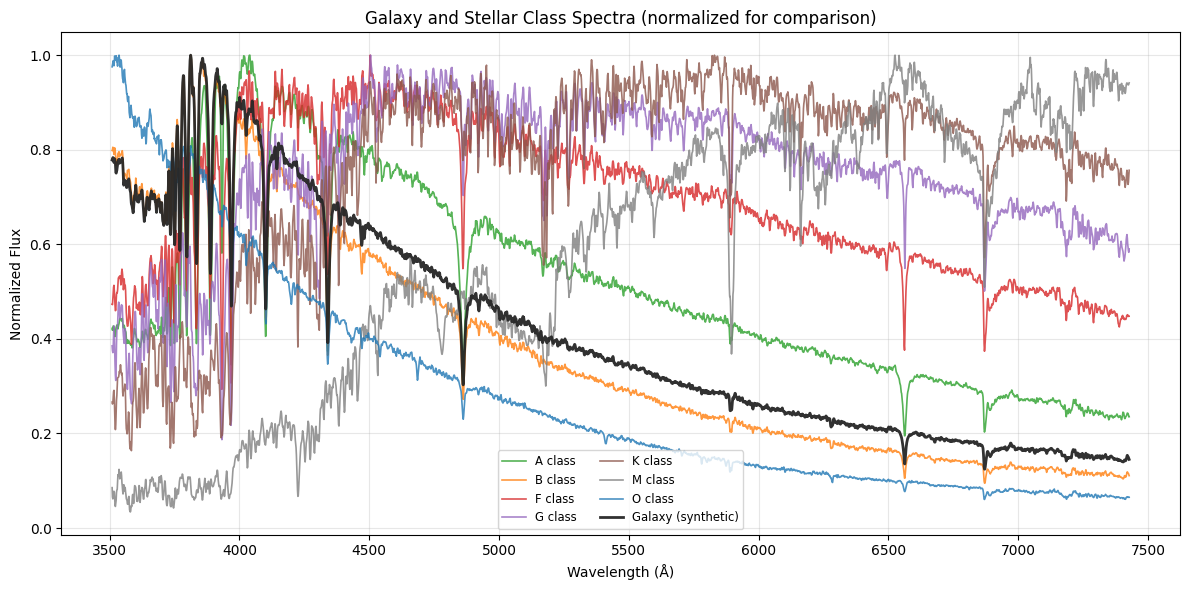

In [49]:
# Combined plot: galaxy spectrum + all class spectra (NORMALIZED for comparison)
# - Normalizes each spectrum by its maximum value so shapes and contributions are comparable
# - Allows visual comparison of which stellar classes contribute what features to the galaxy

import numpy as np
import matplotlib.pyplot as plt

# Check prerequisites
if 'spectra' not in globals() or len(spectra) == 0:
    raise RuntimeError('spectra dictionary not found. Run the earlier loading cell first.')

# Obtain galaxy spectrum (use last_galaxy if present, otherwise try to build a simple example)
wl_gal = None
flux_gal = None
if 'last_galaxy' in globals():
    wl_gal, flux_gal = globals()['last_galaxy']
else:
    try:
        # Use the most recently constructed galaxy components when available so the plotted
        # galaxy represents the synthetic model the user created earlier in the notebook.
        if 'last_galaxy_components' in globals():
            comps_try = globals()['last_galaxy_components']
        elif 'comps' in globals():
            comps_try = globals()['comps']
        elif 'galaxy_size' in globals():
            # If only `galaxy_size` is present, reconstruct components using the same
            # fraction scheme used by the example builder so totals scale with galaxy_size.
            gs = float(globals()['galaxy_size'])
            comps_try = {
                'O': 0.000003 * gs,
                'A': 0.06 * gs,
                'B': 0.013 * gs,
                'F': 0.03 * gs,
                'G': 0.76 * gs,
                'K': 0.121 * gs,
                'M': 0.765 * gs,
            }
        else:
            # No user-provided components: raise to make the situation explicit instead of
            # falling back to arbitrary small example numbers that don't reflect the synthetic galaxy.
            raise RuntimeError('No galaxy components found. Run the galaxy builder example first to create `last_galaxy_components` or set `comps`/`galaxy_size`.')
        wl_gal, flux_gal = build_galaxy_spectrum(comps_try)
    except Exception as e:
        print('No galaxy spectrum available and build attempt failed:', e)

# Classes list (fallback to unique first-letter groups if `classes` not available)
if 'classes' in globals() and isinstance(classes, dict) and len(classes) > 0:
    class_list = sorted(classes.keys())
else:
    # derive classes from spectra keys (first character)
    class_list = sorted({name[0] for name in spectra.keys()})

# Prepare plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.get_cmap('tab10')

for i, cname in enumerate(class_list):
    try:
        wl_c, flux_c = build_class_spectrum(cname)
    except Exception as e:
        # skip missing/unbuildable classes
        print(f'Skipping class {cname}:', e)
        continue

    # Normalize each class spectrum by its maximum value
    if not (hasattr(flux_c, 'size') and flux_c.size):
        print(f'Class {cname} has empty flux array; skipping')
        continue
    
    flux_arr = np.asarray(flux_c, dtype=float)
    maxval = np.nanmax(np.abs(flux_arr))
    if maxval == 0 or not np.isfinite(maxval):
        y_norm = flux_arr
    else:
        y_norm = flux_arr / maxval

    color = class_colors.get(cname, colors(i % 10)) if 'class_colors' in globals() else colors(i % 10)
    ax.plot(wl_c, y_norm, label=f"{cname} class", color=color, lw=1.2, alpha=0.8)

# Plot galaxy if available — normalize it by its maximum value
if wl_gal is not None and flux_gal is not None:
    gal_arr = np.asarray(flux_gal, dtype=float)
    maxval_gal = np.nanmax(np.abs(gal_arr))
    if maxval_gal == 0 or not np.isfinite(maxval_gal):
        gal_norm = gal_arr
    else:
        gal_norm = gal_arr / maxval_gal
    
    ax.plot(wl_gal, gal_norm, color='0.15', lw=2.0, alpha=0.95, label='Galaxy (synthetic)', zorder=10)

ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Normalized Flux')
ax.set_title('Galaxy and Stellar Class Spectra (normalized for comparison)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize='small', ncol=2, loc='best')
plt.tight_layout()
plt.show()


In [50]:
# Read SSP (Simple Stellar Population) FITS files and compare with synthetic galaxy
import os
import glob
import re
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Path to SSP folder (relative to notebook location)
ssp_folder = os.path.join(os.path.dirname(os.path.abspath('Exercise 2 Part IV.ipynb')), 'SSP')
if not os.path.exists(ssp_folder):
    # Try alternative path (current working directory)
    ssp_folder = os.path.join(os.getcwd(), 'SSP')
    if not os.path.exists(ssp_folder):
        raise FileNotFoundError(f'SSP folder not found. Expected at: {ssp_folder}')

print(f'Reading SSP spectra from: {ssp_folder}')

# Find all .fits files matching s*.fits pattern
fits_files = glob.glob(os.path.join(ssp_folder, 's*.fits'))
print(f'Found {len(fits_files)} FITS files')

# Dictionary to store SSP spectra: {age_in_years: {'wl': array, 'flux': array, 'label': str}}
ssp_spectra = {}

def parse_age_from_filename(filename):
    """Extract age in years from filename like s1gy.fits, s100My.fits, s500ky.fits
    Returns (age_in_years, label_string)
    """
    basename = os.path.basename(filename)
    # Match pattern like s1gy, s100My, s500ky
    match = re.match(r's(\d+(?:\.\d+|p\d+)?)(gy|My|ky)\.fits', basename)
    if not match:
        return None, None
    
    number_str = match.group(1).replace('p', '.')  # Handle s5p2My -> 5.2
    number = float(number_str)
    unit = match.group(2)
    
    # Convert to years
    if unit == 'gy':  # Giga years (billion)
        age_years = number * 1e9
        label = f'{number} Gy'
    elif unit == 'My':  # Million years
        age_years = number * 1e6
        label = f'{number} My'
    elif unit == 'ky':  # Kilo years (thousand)
        age_years = number * 1e3
        label = f'{number} ky'
    else:
        return None, None
    
    return age_years, label

# Read each FITS file
for fits_file in fits_files:
    try:
        age_years, label = parse_age_from_filename(fits_file)
        if age_years is None:
            print(f'Warning: Could not parse age from {os.path.basename(fits_file)}')
            continue
        
        # Open FITS file
        with fits.open(fits_file) as hdul:
            # FITS files typically have data in the primary HDU or first extension
            # Try to find the spectrum data
            data = None
            header = None
            
            if len(hdul) > 0 and hdul[0].data is not None:
                data = hdul[0].data
                header = hdul[0].header
            elif len(hdul) > 1:
                data = hdul[1].data
                header = hdul[1].header
            
            if data is None:
                print(f'Warning: No data found in {os.path.basename(fits_file)}')
                continue
            
            # Extract wavelength and flux
            # Common FITS spectrum formats:
            # - 1D array: flux only, wavelength from header (CRVAL1, CDELT1)
            # - 2D array: might be [wavelength, flux] or similar
            
            if data.ndim == 1:
                # 1D flux array, construct wavelength from header
                flux = data
                npoints = len(flux)
                
                # FITS WCS keywords
                crval1 = header.get('CRVAL1', 0)  # Starting wavelength
                cdelt1 = header.get('CDELT1', 1)  # Wavelength step
                crpix1 = header.get('CRPIX1', 1)  # Reference pixel
                
                # Construct wavelength array
                wl = crval1 + (np.arange(npoints) - (crpix1 - 1)) * cdelt1
                
            elif data.ndim == 2:
                # 2D array - try different interpretations
                if data.shape[0] == 2:
                    # [wl, flux]
                    wl = data[0]
                    flux = data[1]
                elif data.shape[1] == 2:
                    # [[wl, flux], [wl, flux], ...]
                    wl = data[:, 0]
                    flux = data[:, 1]
                else:
                    # Take first row/column as wavelength
                    wl = data[0]
                    flux = data[1] if data.shape[0] > 1 else data[:, 1]
            else:
                print(f'Warning: Unexpected data shape {data.shape} in {os.path.basename(fits_file)}')
                continue
            
            # Store in dictionary
            ssp_spectra[age_years] = {
                'wl': np.asarray(wl, dtype=float),
                'flux': np.asarray(flux, dtype=float),
                'label': label
            }
            
            print(f'  Loaded {label}: {len(wl)} points, wl range {wl.min():.1f}-{wl.max():.1f} Å')
            
    except Exception as e:
        print(f'Error reading {os.path.basename(fits_file)}: {e}')

print(f'\nSuccessfully loaded {len(ssp_spectra)} SSP spectra')

# Store in globals for later use
globals()['ssp_spectra'] = ssp_spectra

Reading SSP spectra from: c:\Users\Bruger\Desktop\Rodeskuffen\Astro Assign. 2\Workspace\SSP
Found 10 FITS files
  Loaded 100.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 10.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 13.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 16.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 1.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 20.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 400.0 My: 9300 points, wl range 700.0-9999.0 Å
  Loaded 4.0 Gy: 9300 points, wl range 700.0-9999.0 Å
  Loaded 500.0 ky: 9300 points, wl range 700.0-9999.0 Å
  Loaded 5.2 My: 9300 points, wl range 700.0-9999.0 Å

Successfully loaded 10 SSP spectra


- Compare the overall shape and features to estimate the age of your synthetic galaxy
- Your synthetic galaxy is shown in RED with dashed line
- SSP spectra are color-coded by age (purple=young, yellow=old)

Visual comparison guide:


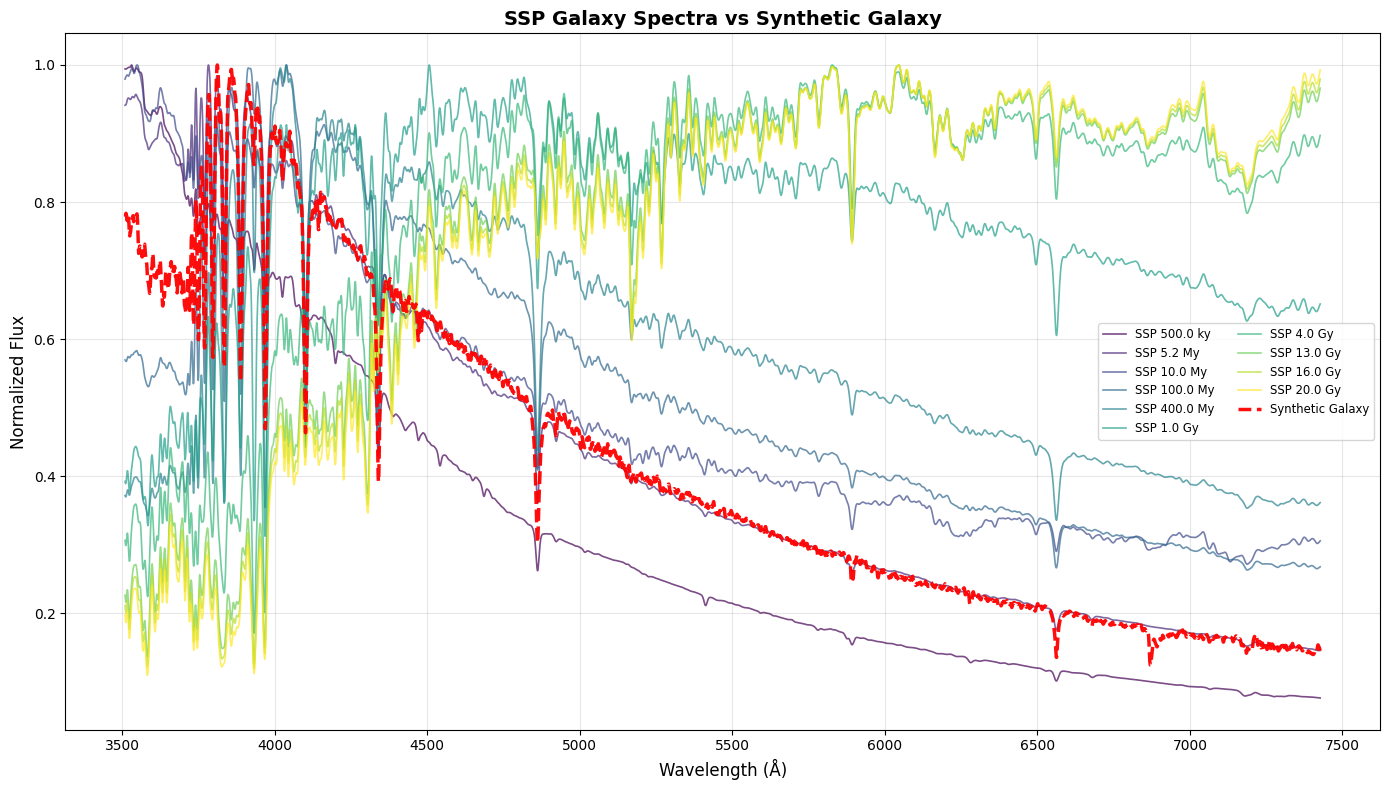

In [51]:
# Plot SSP spectra compared with synthetic galaxy spectrum
import numpy as np
import matplotlib.pyplot as plt

if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0:
    raise RuntimeError('SSP spectra not loaded. Run the previous cell first.')

# Get synthetic galaxy spectrum
if 'last_galaxy' in globals():
    wl_synth, flux_synth = globals()['last_galaxy']
else:
    raise RuntimeError('No synthetic galaxy spectrum found. Run the galaxy builder cell first.')

# Determine wavelength range of synthetic galaxy
wl_min_synth = np.min(wl_synth)
wl_max_synth = np.max(wl_synth)

# Sort SSP spectra by age
ages_sorted = sorted(ssp_spectra.keys())

# Create plot
fig, ax = plt.subplots(figsize=(14, 8))

# Color map for SSP spectra (from young to old)
cmap = plt.get_cmap('viridis')
colors_ssp = [cmap(i / max(1, len(ages_sorted) - 1)) for i in range(len(ages_sorted))]

# Plot each SSP spectrum (normalized, restricted to synthetic galaxy wavelength range)
for i, age in enumerate(ages_sorted):
    spec = ssp_spectra[age]
    wl = spec['wl']
    flux = spec['flux']
    label = spec['label']
    
    # Restrict to synthetic galaxy wavelength range
    mask = (wl >= wl_min_synth) & (wl <= wl_max_synth)
    wl_restricted = wl[mask]
    flux_restricted = flux[mask]
    
    if len(wl_restricted) == 0:
        continue  # Skip if no overlap
    
    # Normalize by maximum value within restricted range
    flux_arr = np.asarray(flux_restricted, dtype=float)
    maxval = np.nanmax(np.abs(flux_arr))
    if maxval > 0 and np.isfinite(maxval):
        flux_norm = flux_arr / maxval
    else:
        flux_norm = flux_arr
    
    ax.plot(wl_restricted, flux_norm, color=colors_ssp[i], lw=1.2, alpha=0.7, label=f'SSP {label}')

# Plot synthetic galaxy (normalized, with thicker line for visibility)
flux_synth_arr = np.asarray(flux_synth, dtype=float)
maxval_synth = np.nanmax(np.abs(flux_synth_arr))
if maxval_synth > 0 and np.isfinite(maxval_synth):
    flux_synth_norm = flux_synth_arr / maxval_synth
else:
    flux_synth_norm = flux_synth_arr

ax.plot(wl_synth, flux_synth_norm, color='red', lw=2.5, alpha=0.95, 
        label='Synthetic Galaxy', zorder=100, linestyle='--')


ax.set_xlabel('Wavelength (Å)', fontsize=12)
print('- Compare the overall shape and features to estimate the age of your synthetic galaxy')

ax.set_ylabel('Normalized Flux', fontsize=12)
print('- Your synthetic galaxy is shown in RED with dashed line')

ax.set_title('SSP Galaxy Spectra vs Synthetic Galaxy', fontsize=14, fontweight='bold')
print('- SSP spectra are color-coded by age (purple=young, yellow=old)')
ax.grid(True, alpha=0.3)
print('\nVisual comparison guide:')

ax.legend(fontsize='small', ncol=2, loc='best')

plt.tight_layout()
plt.show()

In [ ]:
# Interactive comparison: select SSP age to compare directly with synthetic galaxy
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import numpy as np
    import matplotlib.pyplot as plt

    if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0:
        print('SSP spectra not loaded. Run the SSP loading cell first.')
    elif 'last_galaxy' not in globals():
        print('No synthetic galaxy spectrum found. Run the galaxy builder cell first.')
    else:
        # Get synthetic galaxy
        wl_synth, flux_synth = globals()['last_galaxy']
        
        # Determine wavelength range of synthetic galaxy
        wl_min_synth = np.min(wl_synth)
        wl_max_synth = np.max(wl_synth)
        
        # Prepare dropdown options (sorted by age)
        ages_sorted = sorted(ssp_spectra.keys())
        options = [(ssp_spectra[age]['label'], age) for age in ages_sorted]
        
        dropdown = widgets.Dropdown(
            options=options,
            description='SSP Age:',
            value=ages_sorted[len(ages_sorted)//2] if ages_sorted else None  # Start with middle age
        )
        out = widgets.Output()
        
        def on_change(change, out=out):
            if change.get('name') == 'value':
                with out:
                    clear_output(wait=True)
                    age = change.get('new')
                    spec = ssp_spectra[age]
                    wl_ssp = spec['wl']
                    flux_ssp = spec['flux']
                    label_ssp = spec['label']
                    
                    # Restrict SSP to synthetic galaxy wavelength range
                    mask = (wl_ssp >= wl_min_synth) & (wl_ssp <= wl_max_synth)
                    wl_ssp_restricted = wl_ssp[mask]
                    flux_ssp_restricted = flux_ssp[mask]
                    
                    # Normalize both spectra
                    flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float)
                    max_ssp = np.nanmax(np.abs(flux_ssp_arr))
                    if max_ssp > 0 and np.isfinite(max_ssp):
                        flux_ssp_norm = flux_ssp_arr / max_ssp
                    else:
                        flux_ssp_norm = flux_ssp_arr
                    
                    flux_synth_arr = np.asarray(flux_synth, dtype=float)
                    max_synth = np.nanmax(np.abs(flux_synth_arr))
                    if max_synth > 0 and np.isfinite(max_synth):
                        flux_synth_norm = flux_synth_arr / max_synth
                    else:
                        flux_synth_norm = flux_synth_arr
                    
                    # Plot comparison
                    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
                    
                    # Top panel: overlay
                    ax1.plot(wl_ssp_restricted, flux_ssp_norm, color='blue', lw=1.5, alpha=0.8, label=f'SSP {label_ssp}')
                    ax1.plot(wl_synth, flux_synth_norm, color='red', lw=1.5, alpha=0.8, 
                            label='Synthetic Galaxy', linestyle='--')
                    ax1.set_xlabel('Wavelength (Å)')
                    ax1.set_ylabel('Normalized Flux')
                    ax1.set_title(f'Comparison: SSP {label_ssp} vs Synthetic Galaxy')
                    ax1.grid(True, alpha=0.3)
                    ax1.legend(fontsize='medium')
                    
                    # Bottom panel: residual (interpolate SSP to synthetic wavelength grid)
                    flux_ssp_interp = np.interp(wl_synth, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan)
                    residual = flux_synth_norm - flux_ssp_interp
                    
                    ax2.plot(wl_synth, residual, color='purple', lw=1.0)
                    ax2.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5)
                    ax2.set_xlabel('Wavelength (Å)')
                    ax2.set_ylabel('Residual (Synth - SSP)')
                    ax2.set_title('Residual Spectrum')
                    ax2.grid(True, alpha=0.3)
                    
                    # Calculate RMS of residual (excluding NaNs)
                    valid = ~np.isnan(residual)
                    if np.any(valid):
                        rms = np.sqrt(np.nanmean(residual[valid]**2))
                        # Calculate correlation coefficient
                        corr_matrix = np.corrcoef(flux_synth_norm[valid], flux_ssp_interp[valid])
                        correlation = corr_matrix[0, 1]
                        corr_percent = correlation * 100
                        
                        ax2.text(0.02, 0.98, f'RMS = {rms:.4f}\nCorrelation = {corr_percent:.2f}%', 
                                transform=ax2.transAxes, fontsize=10,
                                verticalalignment='top',
                                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                    
                    plt.tight_layout()
                    plt.show()
        
        dropdown.observe(on_change, names='value')
        display(dropdown, out)
        
        # Trigger initial plot
        on_change({'name': 'value', 'new': dropdown.value})

except Exception as e:
    print('Interactive comparison requires ipywidgets:', e)
    print('Install with: pip install ipywidgets')

Dropdown(description='SSP Age:', index=5, options=(('500.0 ky', 500000.0), ('5.2 My', 5200000.0), ('10.0 My', …

Output()

In [53]:
# Read observed galaxy spectra (gal1.fits and gal2.fits)
import os
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Path to workspace folder
workspace_folder = os.getcwd()

# Dictionary to store observed galaxies
observed_galaxies = {}

for gal_name in ['gal1', 'gal2']:
    gal_file = os.path.join(workspace_folder, f'{gal_name}.fits')
    
    if not os.path.exists(gal_file):
        print(f'Warning: {gal_name}.fits not found at {gal_file}')
        continue
    
    try:
        with fits.open(gal_file) as hdul:
            # Try to find the spectrum data
            data = None
            header = None
            
            if len(hdul) > 0 and hdul[0].data is not None:
                data = hdul[0].data
                header = hdul[0].header
            elif len(hdul) > 1:
                data = hdul[1].data
                header = hdul[1].header
            
            if data is None:
                print(f'Warning: No data found in {gal_name}.fits')
                continue
            
            # Extract wavelength and flux
            if data.ndim == 1:
                # 1D flux array, construct wavelength from header
                flux = data
                npoints = len(flux)
                
                # FITS WCS keywords
                crval1 = header.get('CRVAL1', 0)
                cdelt1 = header.get('CDELT1', 1)
                crpix1 = header.get('CRPIX1', 1)
                
                # Construct wavelength array
                wl = crval1 + (np.arange(npoints) - (crpix1 - 1)) * cdelt1
                
            elif data.ndim == 2:
                # 2D array
                if data.shape[0] == 2:
                    wl = data[0]
                    flux = data[1]
                elif data.shape[1] == 2:
                    wl = data[:, 0]
                    flux = data[:, 1]
                else:
                    wl = data[0]
                    flux = data[1] if data.shape[0] > 1 else data[:, 1]
            else:
                print(f'Warning: Unexpected data shape {data.shape} in {gal_name}.fits')
                continue
            
            # Store in dictionary
            observed_galaxies[gal_name] = {
                'wl': np.asarray(wl, dtype=float),
                'flux': np.asarray(flux, dtype=float)
            }
            
            print(f'Loaded {gal_name}: {len(wl)} points, wl range {wl.min():.1f}-{wl.max():.1f} Å')
            
    except Exception as e:
        print(f'Error reading {gal_name}.fits: {e}')

print(f'\nSuccessfully loaded {len(observed_galaxies)} observed galaxy spectra')

# Store in globals for later use
globals()['observed_galaxies'] = observed_galaxies

Loaded gal1: 1743 points, wl range 1235.0-9945.0 Å
Loaded gal2: 1741 points, wl range 1235.0-9935.0 Å

Successfully loaded 2 observed galaxy spectra


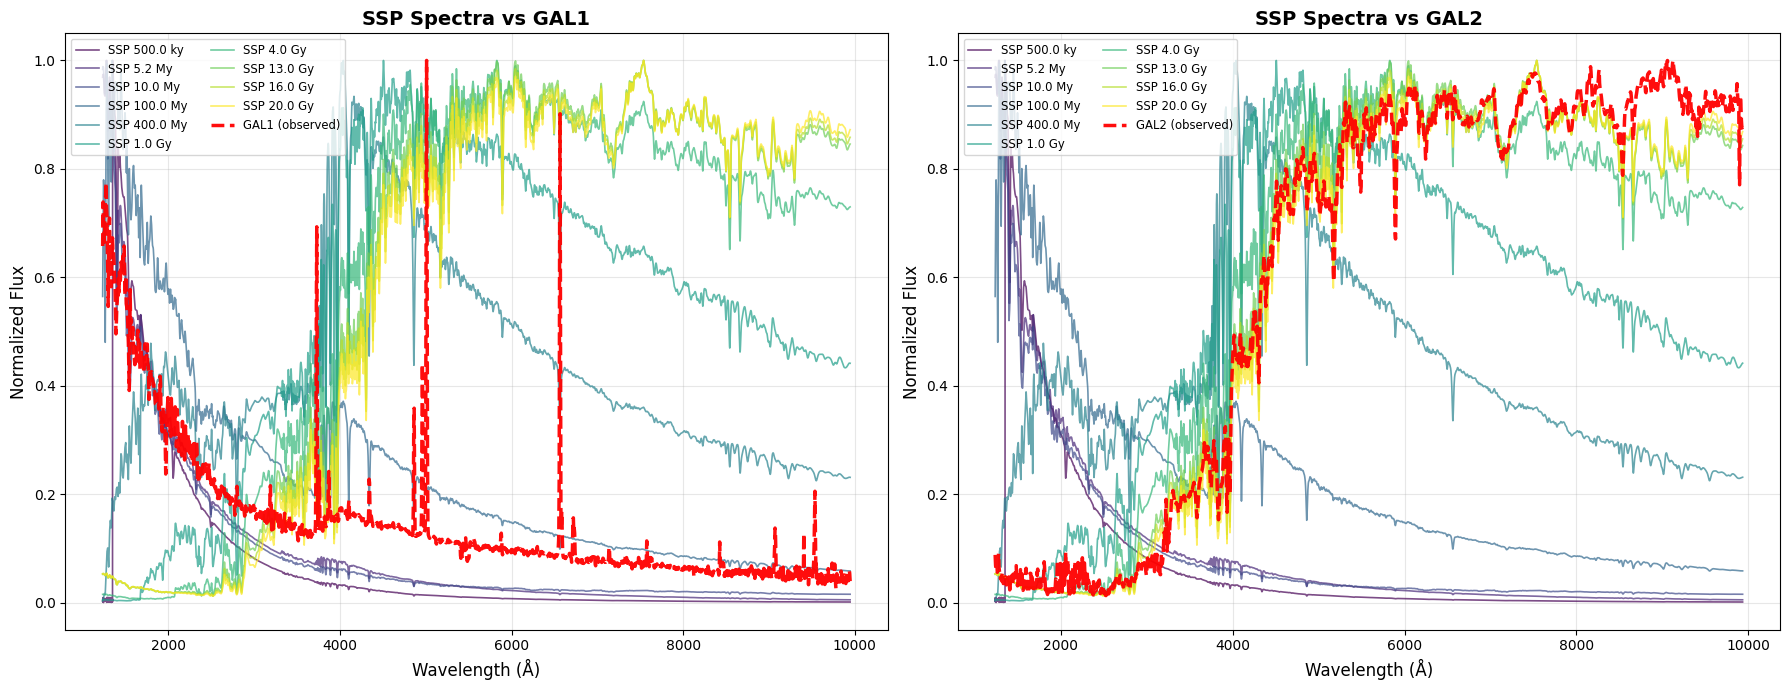


Visual comparison guide:
- SSP spectra are color-coded by age (purple=young, yellow=old)
- Observed galaxies are shown in RED with dashed lines
- Compare the overall shape and features to estimate the age of each galaxy


In [54]:
# Plot SSP spectra compared with gal1 and gal2
import numpy as np
import matplotlib.pyplot as plt

if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0:
    raise RuntimeError('SSP spectra not loaded. Run the SSP loading cell first.')

if 'observed_galaxies' not in globals() or len(observed_galaxies) == 0:
    raise RuntimeError('Observed galaxies not loaded. Run the previous cell first.')

# Sort SSP spectra by age
ages_sorted = sorted(ssp_spectra.keys())

# Color map for SSP spectra (from young to old)
cmap = plt.get_cmap('viridis')
colors_ssp = [cmap(i / max(1, len(ages_sorted) - 1)) for i in range(len(ages_sorted))]

# Create subplots for gal1 and gal2
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, (gal_name, gal_data) in enumerate(sorted(observed_galaxies.items())):
    ax = axes[idx]
    wl_obs = gal_data['wl']
    flux_obs = gal_data['flux']
    
    # Determine wavelength range of observed galaxy
    wl_min_obs = np.min(wl_obs)
    wl_max_obs = np.max(wl_obs)
    
    # Plot each SSP spectrum (normalized, restricted to observed galaxy wavelength range)
    for i, age in enumerate(ages_sorted):
        spec = ssp_spectra[age]
        wl = spec['wl']
        flux = spec['flux']
        label = spec['label']
        
        # Restrict to observed galaxy wavelength range
        mask = (wl >= wl_min_obs) & (wl <= wl_max_obs)
        wl_restricted = wl[mask]
        flux_restricted = flux[mask]
        
        if len(wl_restricted) == 0:
            continue
        
        # Normalize by maximum value within restricted range
        flux_arr = np.asarray(flux_restricted, dtype=float)
        maxval = np.nanmax(np.abs(flux_arr))
        if maxval > 0 and np.isfinite(maxval):
            flux_norm = flux_arr / maxval
        else:
            flux_norm = flux_arr
        
        ax.plot(wl_restricted, flux_norm, color=colors_ssp[i], lw=1.2, alpha=0.7, label=f'SSP {label}')
    
    # Plot observed galaxy (normalized, with thicker line for visibility)
    flux_obs_arr = np.asarray(flux_obs, dtype=float)
    maxval_obs = np.nanmax(np.abs(flux_obs_arr))
    if maxval_obs > 0 and np.isfinite(maxval_obs):
        flux_obs_norm = flux_obs_arr / maxval_obs
    else:
        flux_obs_norm = flux_obs_arr
    
    ax.plot(wl_obs, flux_obs_norm, color='red', lw=2.5, alpha=0.95, 
            label=f'{gal_name.upper()} (observed)', zorder=100, linestyle='--')
    
    ax.set_xlabel('Wavelength (Å)', fontsize=12)
    ax.set_ylabel('Normalized Flux', fontsize=12)
    ax.set_title(f'SSP Spectra vs {gal_name.upper()}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize='small', ncol=2, loc='best')

plt.tight_layout()
plt.show()

print('\nVisual comparison guide:')
print('- SSP spectra are color-coded by age (purple=young, yellow=old)')
print('- Observed galaxies are shown in RED with dashed lines')
print('- Compare the overall shape and features to estimate the age of each galaxy')

In [ ]:
# Interactive comparison for gal1 and gal2: select galaxy and SSP age to compare
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    import numpy as np
    import matplotlib.pyplot as plt

    if 'ssp_spectra' not in globals() or len(ssp_spectra) == 0:
        print('SSP spectra not loaded. Run the SSP loading cell first.')
    elif 'observed_galaxies' not in globals() or len(observed_galaxies) == 0:
        print('Observed galaxies not loaded. Run the galaxy loading cell first.')
    else:
        # Prepare dropdown options
        ages_sorted = sorted(ssp_spectra.keys())
        age_options = [(ssp_spectra[age]['label'], age) for age in ages_sorted]
        gal_options = sorted(observed_galaxies.keys())
        
        # Create widgets
        gal_dropdown = widgets.Dropdown(
            options=gal_options,
            description='Galaxy:',
            value=gal_options[0] if gal_options else None
        )
        age_dropdown = widgets.Dropdown(
            options=age_options,
            description='SSP Age:',
            value=ages_sorted[len(ages_sorted)//2] if ages_sorted else None
        )
        out = widgets.Output()
        
        def on_change(change=None, out=out):
            with out:
                clear_output(wait=True)
                
                gal_name = gal_dropdown.value
                age = age_dropdown.value
                
                # Get observed galaxy data
                wl_obs = observed_galaxies[gal_name]['wl']
                flux_obs = observed_galaxies[gal_name]['flux']
                
                # Determine wavelength range
                wl_min_obs = np.min(wl_obs)
                wl_max_obs = np.max(wl_obs)
                
                # Get SSP data
                spec = ssp_spectra[age]
                wl_ssp = spec['wl']
                flux_ssp = spec['flux']
                label_ssp = spec['label']
                
                # Restrict SSP to observed galaxy wavelength range
                mask = (wl_ssp >= wl_min_obs) & (wl_ssp <= wl_max_obs)
                wl_ssp_restricted = wl_ssp[mask]
                flux_ssp_restricted = flux_ssp[mask]
                
                # Normalize both spectra
                flux_ssp_arr = np.asarray(flux_ssp_restricted, dtype=float)
                max_ssp = np.nanmax(np.abs(flux_ssp_arr))
                if max_ssp > 0 and np.isfinite(max_ssp):
                    flux_ssp_norm = flux_ssp_arr / max_ssp
                else:
                    flux_ssp_norm = flux_ssp_arr
                
                flux_obs_arr = np.asarray(flux_obs, dtype=float)
                max_obs = np.nanmax(np.abs(flux_obs_arr))
                if max_obs > 0 and np.isfinite(max_obs):
                    flux_obs_norm = flux_obs_arr / max_obs
                else:
                    flux_obs_norm = flux_obs_arr
                
                # Plot comparison
                fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
                
                # Top panel: overlay
                ax1.plot(wl_ssp_restricted, flux_ssp_norm, color='blue', lw=1.5, alpha=0.8, label=f'SSP {label_ssp}')
                ax1.plot(wl_obs, flux_obs_norm, color='red', lw=1.5, alpha=0.8, 
                        label=f'{gal_name.upper()} (observed)', linestyle='--')
                ax1.set_xlabel('Wavelength (Å)')
                ax1.set_ylabel('Normalized Flux')
                ax1.set_title(f'Comparison: SSP {label_ssp} vs {gal_name.upper()}')
                ax1.grid(True, alpha=0.3)
                ax1.legend(fontsize='medium')
                
                # Bottom panel: residual (interpolate SSP to observed wavelength grid)
                flux_ssp_interp = np.interp(wl_obs, wl_ssp_restricted, flux_ssp_norm, left=np.nan, right=np.nan)
                residual = flux_obs_norm - flux_ssp_interp
                
                ax2.plot(wl_obs, residual, color='purple', lw=1.0)
                ax2.axhline(0, color='black', linestyle='-', lw=0.8, alpha=0.5)
                ax2.set_xlabel('Wavelength (Å)')
                ax2.set_ylabel('Residual (Obs - SSP)')
                ax2.set_title('Residual Spectrum')
                ax2.grid(True, alpha=0.3)
                
                # Calculate RMS of residual (excluding NaNs)
                valid = ~np.isnan(residual)
                if np.any(valid):
                    rms = np.sqrt(np.nanmean(residual[valid]**2))
                    # Calculate correlation coefficient
                    corr_matrix = np.corrcoef(flux_obs_norm[valid], flux_ssp_interp[valid])
                    correlation = corr_matrix[0, 1]
                    corr_percent = correlation * 100
                    
                    ax2.text(0.02, 0.98, f'RMS = {rms:.4f}\nCorrelation = {corr_percent:.2f}%', 
                            transform=ax2.transAxes, fontsize=10,
                            verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
                
                plt.tight_layout()
                plt.show()
        
        gal_dropdown.observe(on_change, names='value')
        age_dropdown.observe(on_change, names='value')
        display(widgets.HBox([gal_dropdown, age_dropdown]), out)
        
        # Trigger initial plot
        on_change()

except Exception as e:
    print('Interactive comparison requires ipywidgets:', e)
    print('Install with: pip install ipywidgets')

Output()